## Plotting the Synthetic Observations

In [100]:
import sys
sys.path.append('../src')
from realstar_synthetic_observations import Observations
import torch
import os
import numpy as np
from astropy.io import fits
from astropy import constants as const
from scipy.interpolate import interp1d
from transformer import shift_spectrum
#for interactive plotting
%matplotlib inline 
import matplotlib.pyplot as plt


In [101]:
val_data_file = 'SPIRou30_val.df'
nspec = 3
order = 30

obs_to_plot = Observations(i=0, seed=0, SNR=50, filepath="../data/validation_data/"+val_data_file, 
                   N=nspec, order=order, star='barnards')

synthetic_spectra_toplot, uncertainty = obs_to_plot.make_observations(func='connors', add_RV=True)
synthetic_spectra_toplot, uncertainty = obs_to_plot.post_process()
non_ones = torch.where(obs_to_plot.padded_wgrid != 1)

In [102]:
#we can see that the BERV has been calculated using coordinates
obs_to_plot.berv

tensor([ 14014.0352, -13659.5426,  14215.0915])

In [103]:
# wavelength grid for the synthetic observations
print(len(obs_to_plot.inst_wgrid))
inst_wgrid = obs_to_plot.inst_wgrid.cpu().numpy()

print(f'The wavelength range is {inst_wgrid[0]:.4f}nm to {inst_wgrid[-1]:.4f}nm')

4088
The wavelength range is 1542.5102nm to 1591.2048nm


In [104]:
#we need to convert the tensor to a numpy array and move the data to CPU

synthetic_spectra_toplot = synthetic_spectra_toplot[0].cpu().numpy()
np.shape(synthetic_spectra_toplot)

(3, 4088)

<Figure size 640x480 with 0 Axes>

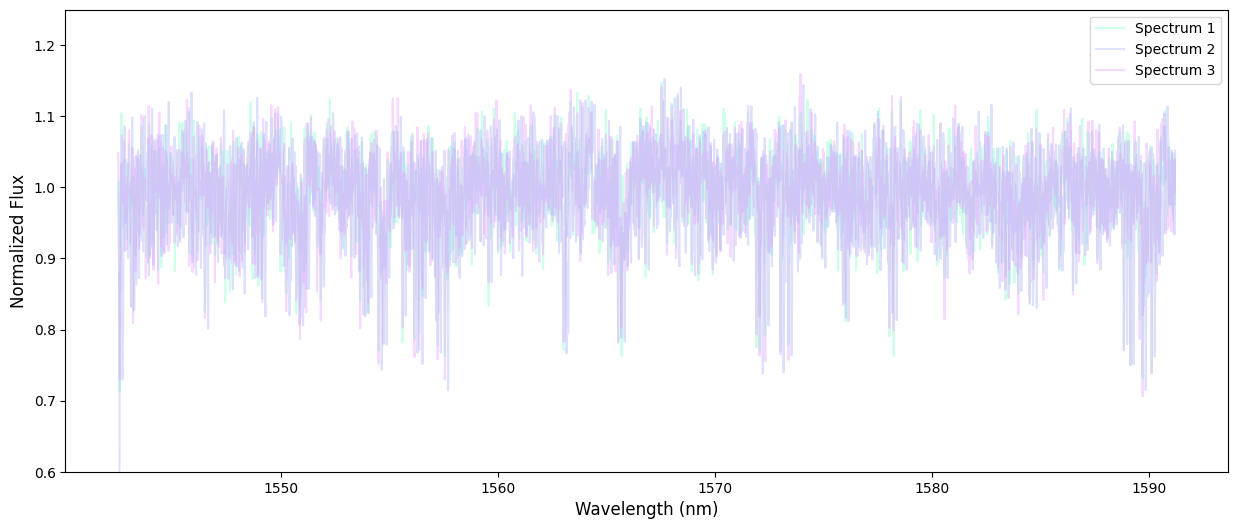

In [105]:
#plotting loop

plt.clf() 
plt.figure(figsize = (15, 6))
c_list = ['#84FFC9', '#AAB2FF', '#ECA0FF']
for i in range(nspec):
    plt.plot(inst_wgrid, synthetic_spectra_toplot[i,] , label = f'Spectrum {i + 1}', c=c_list[i], alpha = 0.4)
    
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Normalized Flux', fontsize = 12)
plt.legend()
plt.ylim(0.2, 1.25)
#plt.xlim(1035, 1038)
#plt.savefig('Synthetic_obs.png')
plt.ylim(0.6,1.25)

plt.show()

## Plotting the Barnard's Star Observations

In [106]:
barnards_data_filepath = '../data/Barnard\'s_Star_Data/'
with fits.open(barnards_data_filepath + '2400804t.fits') as hdul:
    hdul.info()
    primary_header = hdul[0].header
    fluxab_header = hdul[1].header
    display(fluxab_header)
    print(f'The BERV of this observation is: {fluxab_header["BERV"]} km/s')
    berv_from_file = fluxab_header["BERV"]  #get the BERV of that observation
    snr_key = f"EXTSN{order:03d}"
    snr = fluxab_header[snr_key]

    print(f"SNR for order {order}: {snr:.4f}")  
    
    wavelength = hdul['WaveAB'].data[order, :] # get the wavelengths
    flux = hdul['FluxAB'].data[order, : ] # also get flux
    blaze_correction = hdul['BlazeAB'].data[order, :] #get the blaze correction
    blaze_header = hdul['BlazeAB'].header


    #get the value they used for the systemic RV
    sys_velocity = fluxab_header["PP_RV"]
    telluric_vel = fluxab_header["MKT_ARV "]    #note that the header provides it to you in m/s
    print(f'The systemic velocity for this observation is {sys_velocity/(1e3)} km/s') 

    recon = hdul['Recon'].data[order, :]
    

    
#display(data)

Filename: ../data/Barnard's_Star_Data/2400804t.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     502   ()      
  1  FluxAB        1 ImageHDU      1140   (4088, 49)   float64   
  2  WaveAB        1 ImageHDU       803   (4088, 49)   float64   
  3  BlazeAB       1 ImageHDU       351   (4088, 49)   float64   
  4  Recon         1 ImageHDU      1140   (4088, 49)   float64   
  5  OHLine        1 ImageHDU      1136   (4088, 49)   float64   
  6  FluxA         1 ImageHDU      1140   (4088, 49)   float64   
  7  WaveA         1 ImageHDU       803   (4088, 49)   float64   
  8  BlazeA        1 ImageHDU       351   (4088, 49)   float64   
  9  FluxB         1 ImageHDU      1140   (4088, 49)   float64   
 10  WaveB         1 ImageHDU       803   (4088, 49)   float64   
 11  BlazeB        1 ImageHDU       351   (4088, 49)   float64   


XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 4088                                                  
NAXIS2  =                   49                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
FILENAME= '2400804o'           / filename anticipated by fitspipe server        
PATHNAME= '/data/sessions/spirou/19AQ08-Apr20' / Original directory name at acqu
DATE    = '2019-04-21T13:43:15' / UTC Date of file creation                     
HSTTIME = 'Sun Apr 21 03:43:15 HST 2019' / Local time in Hawaii                 
IMAGESWV= 'DetCom-SPIRou v1.14 svn 12728 (compiled Jan 17 2019)' / Image creatio
IMAGELBV= 'CFHT libdetcom v1

The BERV of this observation is: 22.54152605160215 km/s
SNR for order 30: 146.7774
The systemic velocity for this observation is -110.11 km/s


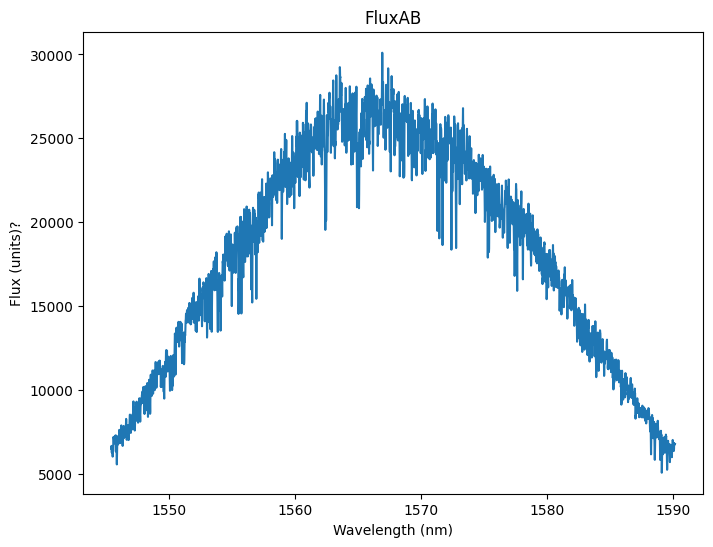

In [107]:
#plot the flux

plt.figure(figsize=(8,6))
plt.plot(wavelength, flux)
plt.title('FluxAB')
plt.xlabel('Wavelength (nm)') ; plt.ylabel('Flux (units)?')
plt.savefig('FluxAB.png')
plt.show()


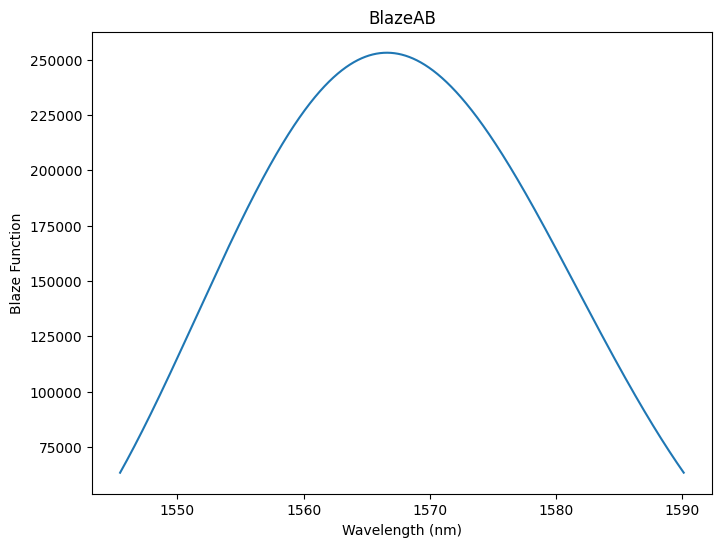

In [108]:
#plot the blaze function

plt.figure(figsize=(8,6))
plt.plot(wavelength, blaze_correction)
plt.title('BlazeAB')
plt.xlabel('Wavelength (nm)') ; plt.ylabel('Blaze Function')
plt.savefig('BlazeAB.png')
plt.show()

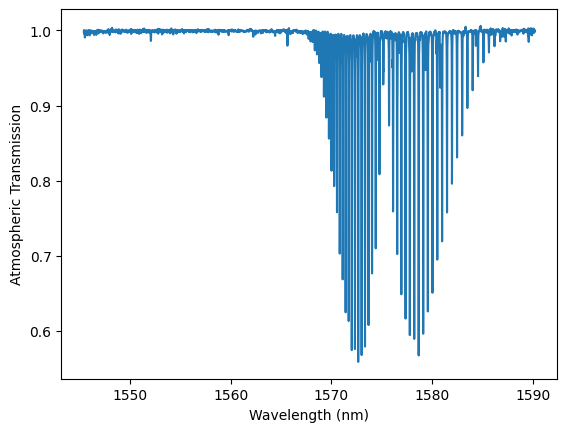

In [109]:
plt.plot(wavelength, recon)
plt.xlabel('Wavelength (nm)') ; plt.ylabel('Atmospheric Transmission')
plt.show()

In [110]:
#remove the blaze function in the flux

nan_count = np.isnan(flux).sum()
flux_blaze_corrected = flux/blaze_correction
print(f'The number of NaNs in the flux data is {nan_count}')

The number of NaNs in the flux data is 325


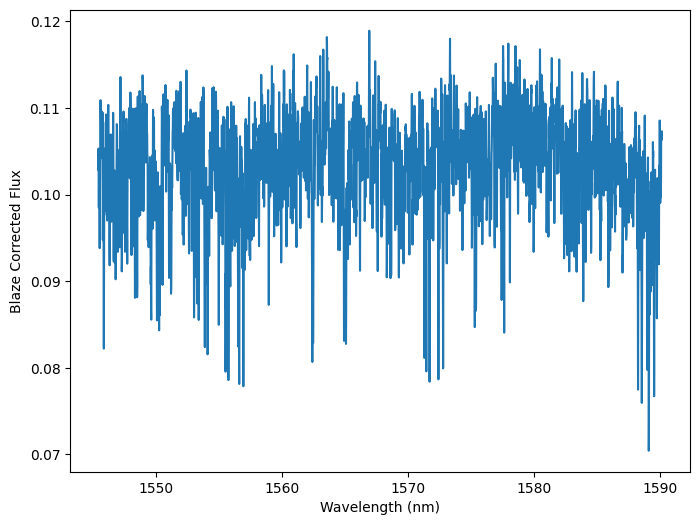

In [111]:
#plot the blaze corrected flux

plt.figure(figsize = (8, 6))
plt.plot(wavelength, flux_blaze_corrected)
plt.xlabel('Wavelength (nm)') ; plt.ylabel('Blaze Corrected Flux')
plt.savefig('blaze_corrected_flux.png')
plt.show()

### This is me attempting to normalize the spectrum
Doing the same idea that is seen in the realstar_synthetic_observations file

In [112]:
# clean out the NaN values

nan_mask = ~np.isnan(wavelength) & ~np.isnan(flux_blaze_corrected)
wave_clean = wavelength[nan_mask]
flux_clean = flux_blaze_corrected[nan_mask]

nbins = 150   #you can adjust this as you want
bins = np.linspace(wave_clean.min(), wave_clean.max(), nbins + 1)
inds = np.digitize(wave_clean, bins)

In [113]:
#this is looping through each wavelength bin and computing the median in each bin

w_med = [] ; f_med = []
for i in range(1, nbins + 1):
    bin_mask = (inds == i)
    if np.any(bin_mask):
        w_med.append(np.median(wave_clean[bin_mask]))
        f_med.append(np.median(flux_clean[bin_mask]))

w_med = np.array(w_med)
f_med = np.array(f_med)

In [114]:
#once the medians are calculated, fit a linear line to those
#this will estimate the continuum

coeffs = np.polyfit(w_med, f_med, 1)
continuum = np.polyval(coeffs, wave_clean)

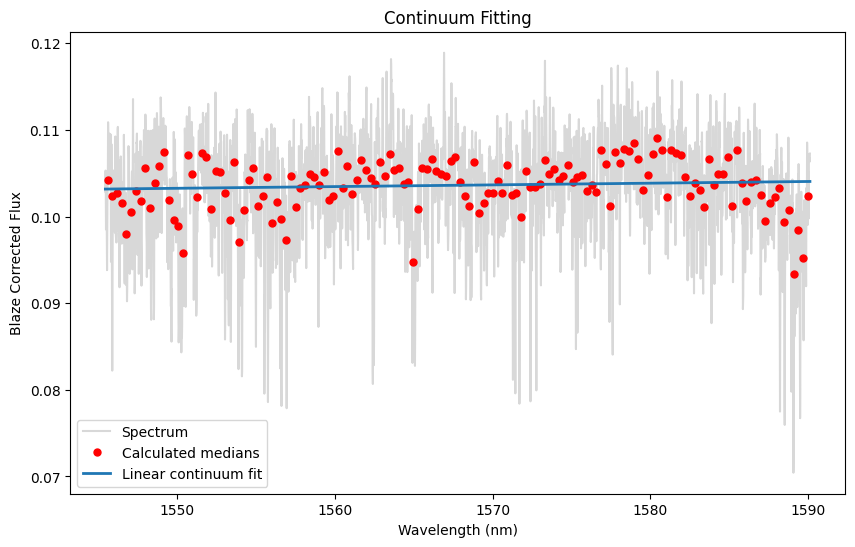

In [115]:
#continuum fitting

plt.figure(figsize=(10, 6))
plt.plot(wave_clean, flux_clean, markersize=1, alpha=0.3, color='grey', label='Spectrum')
plt.plot(w_med, f_med, 'ro', markersize=5, label='Calculated medians')
plt.plot(wave_clean, continuum, '-', linewidth=2, label='Linear continuum fit')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Blaze Corrected Flux')
plt.title('Continuum Fitting')
plt.legend()
plt.savefig('Continuum_fitting.png')
plt.show()

In [116]:
#divide the flux by the continuum, and then divide that by the median to normalize

flux_normalized_clean = flux_clean / continuum
norm_flux = flux_normalized_clean / np.median(flux_normalized_clean)

norm_flux = np.full_like(flux_blaze_corrected, np.nan)
norm_flux[nan_mask] = flux_normalized_clean

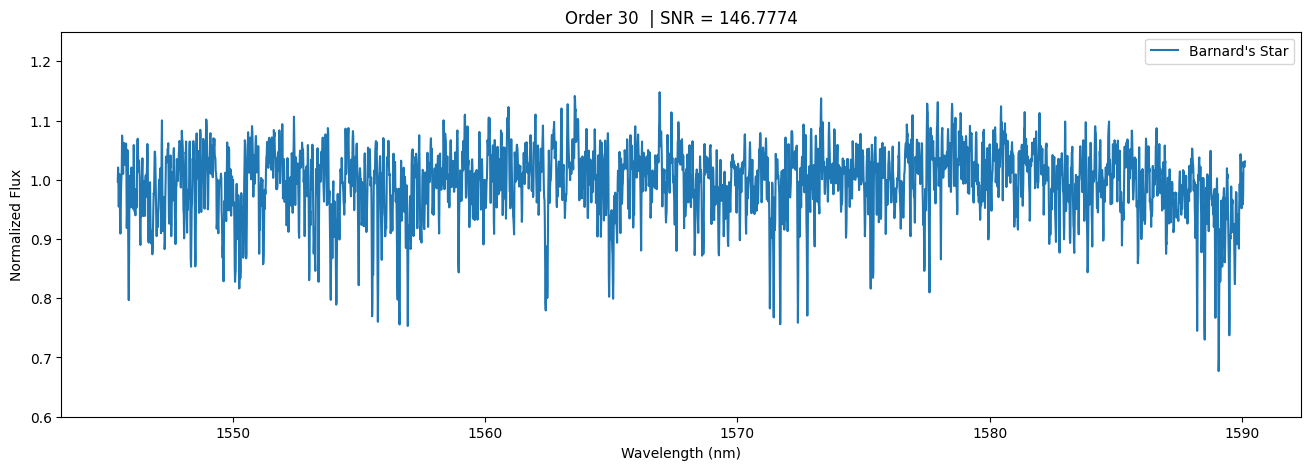

In [117]:
#plot the normalized spectrum
plt.figure(figsize = (16, 5))
plt.plot(wavelength, norm_flux, label="Barnard's Star")
plt.title(f'Order {order}  | SNR = {snr:.4f}')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Flux')
plt.legend()
#plt.savefig('Final_processed_Barnard_spectrum.png')
plt.ylim(0.6,1.25)

plt.show()

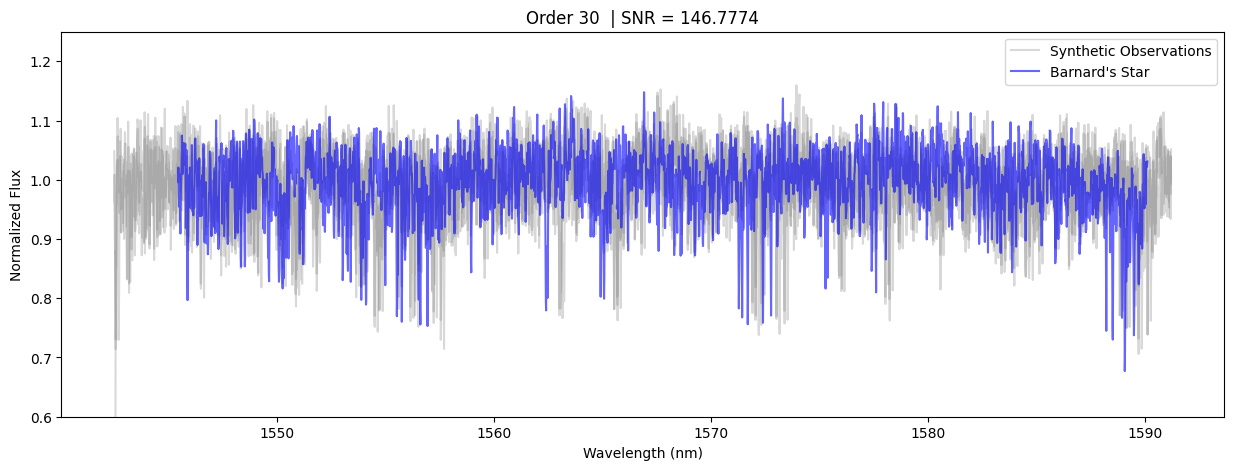

In [118]:

#let's see how the synthetic and our data compare
plt.figure(figsize = (15, 5))
for i in range(nspec):
    if i == 0:
        plt.plot(inst_wgrid, synthetic_spectra_toplot[i,] , label = 'Synthetic Observations', alpha = 0.3, c='grey')
    else:      
        plt.plot(inst_wgrid, synthetic_spectra_toplot[i,] , alpha = 0.3, c='grey')

plt.plot(wavelength,norm_flux, label="Barnard's Star", color = 'blue', alpha = 0.6)
plt.title(f'Order {order}  | SNR = {snr:.4f}')
plt.ylim(0.6,1.25)
plt.legend()
plt.xlabel('Wavelength (nm)') ; plt.ylabel('Normalized Flux')
plt.savefig('Barnard_and_synth_obs.png')
plt.show()

We need to apply a shift to our synthetic data to align it to Barnard's data. Two needs in this case will need to be accounted for right now.
- Account for the systemic RV of Barnard's star. On Wikipedia, this number is given as: −110.47±0.13 km/s (coming from a GAIA data release). Conviently, this number is also found in the header of our data -> "PP_RV"
- We also need to account for the BERV of our observation. This is also found in the header as "BERV"
- Planetary RVs would be subpixel so we are not considering them right now.
I note that it is the data header and NOT the primary header they are found in.

The way that we are going to want to do this is generate the synthetic observation with no RV at all. Then after they are generated, we will apply a Doppler shift to them accounting for both the systemic and the BERV. 


In [119]:
#create synthetic observations with no RV

obs_zero = Observations(i=0, seed=0, SNR=50, filepath="../data/validation_data/"+val_data_file, N=nspec, order=order, star='barnards')

# to prevent shifts, we call add_RV=False
synthetic_zero, uncertainty_zero = obs_zero.make_observations(func='connors', add_RV=False)  #add_RV = False will generate obs. with no RV
synthetic_zero, uncertainty_zero = obs_zero.post_process()
#check our observations have no rv
print(f'The velocity of our observation is {obs_zero.RV}')

The velocity of our observation is 0


In [125]:
#and we need to calculate the total required shift

total_shift_km_s = sys_velocity/1000 - berv_from_file # + telluric_vel/1000  # km/s

print(f'Systemic velocity: {sys_velocity/1000:.2f} km/s')
print(f'BERV from observation: {berv_from_file:.2f} km/s')

#convert to km/s
print(f'Total shift to apply: {total_shift_km_s:.2f} km/s')

Systemic velocity: -110.11 km/s
BERV from observation: 22.54 km/s
Total shift to apply: -132.65 km/s


In [126]:
#this is where we actually apply the shift based on the velocity

flux_shifted = obs_zero.apply_velocity_shift(synthetic_zero, total_shift_km_s)
flux_shifted = flux_shifted[0].cpu().numpy()

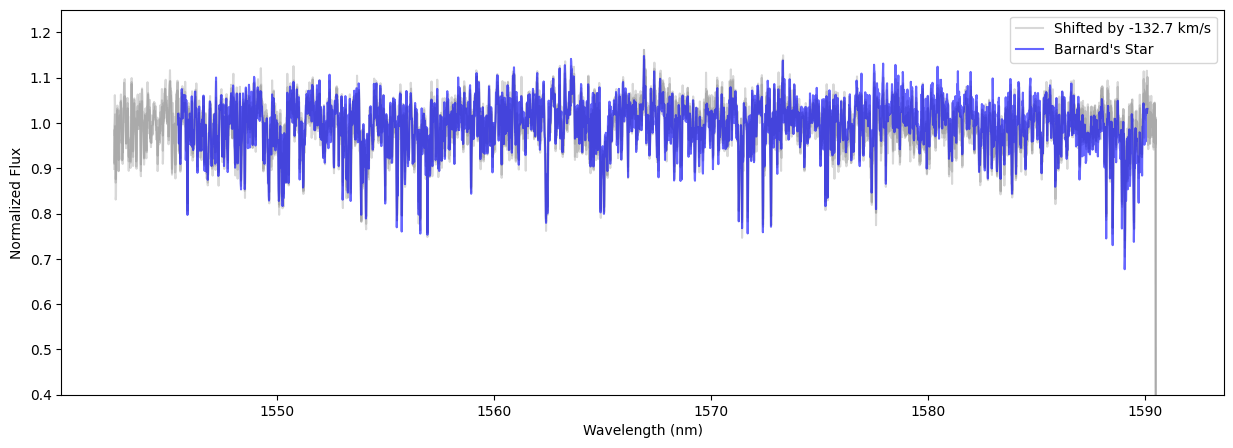

In [127]:
# Now compare with real observations
plt.figure(figsize=(15, 5))
for i in range(0, len(flux_shifted)):
    if i ==0:
        plt.plot(wavelength, flux_shifted[i], 'grey', label=f'Shifted by {total_shift_km_s:.1f} km/s', alpha=0.3)
    else:
        plt.plot(wavelength, flux_shifted[i], 'grey', alpha=0.3)
plt.plot(wavelength, norm_flux, 'blue', label='Barnard\'s Star', alpha=0.6)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Flux')
plt.legend()
plt.ylim(0.4,1.25)
plt.show()